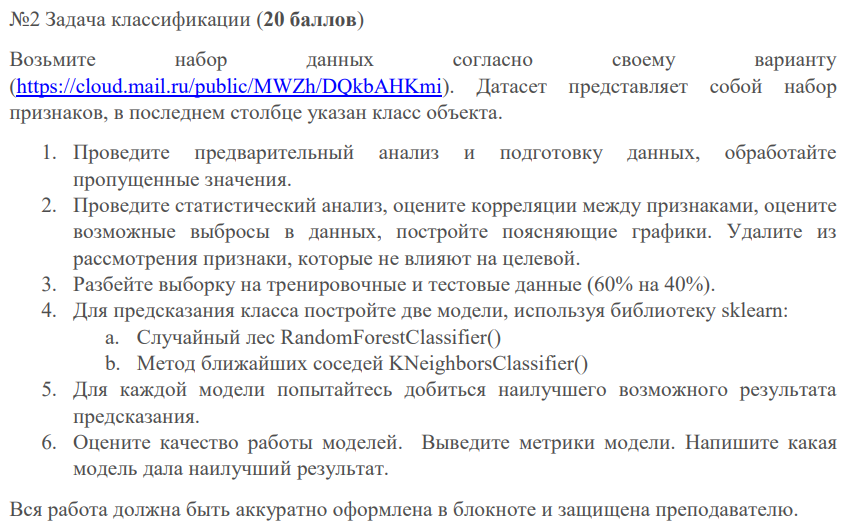

### Импорт и настройка

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score
import warnings
from sklearn.inspection import permutation_importance
warnings.filterwarnings('ignore')

# Настройка визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

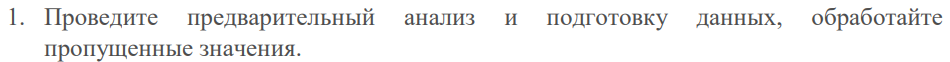

In [15]:
df = pd.read_csv('dataset_class.csv',sep=';',header=None)

df_columns = ["F_0","F_1","F_2","F_3","F_4","F_5","F_6"]
df.columns = df_columns + ['Class']

print(f"Размер набора данных: {df.shape}")
print(f"\nПервые строчки:\n{df.head()}")

Размер набора данных: (100, 8)

Первые строчки:
        F_0       F_1       F_2       F_3        F_4       F_5       F_6  \
0  1.022349 -1.152965 -3.238175 -1.743403   1.022349  0.039865  0.164276   
1  1.818034  1.253846  1.563850 -0.184482   1.818034  1.698031 -1.284481   
2  0.394051  0.001012 -0.087752 -0.216205   3.517162 -0.508531 -1.268684   
3 -0.023390  0.865101 -2.377079 -0.941420  -0.023390 -1.194657 -1.101218   
4  1.750147 -2.047214  0.875766 -0.424756  14.281085  1.939664  1.313150   

   Class  
0      1  
1      2  
2      0  
3      1  
4      2  


In [3]:
print("\nИнформация о наборе данных:")
print(df.info())
print(f"\nСтатистика по признакам:\n{df.describe()}")


Информация о наборе данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   F_0     100 non-null    float64
 1   F_1     100 non-null    float64
 2   F_2     100 non-null    float64
 3   F_3     95 non-null     float64
 4   F_4     100 non-null    float64
 5   F_5     100 non-null    float64
 6   F_6     95 non-null     float64
 7   Class   100 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 6.4 KB
None

Статистика по признакам:
              F_0         F_1         F_2        F_3         F_4         F_5  \
count  100.000000  100.000000  100.000000  95.000000  100.000000  100.000000   
mean     0.316960   -0.009130    0.428606   0.024382    0.643731   -0.277801   
std      1.288587    1.088681    1.609151   0.744807    2.399867    1.232582   
min     -2.411618   -2.317990   -3.238175  -1.743403   -2.411618   -3.635480   
25%     -0.615729

In [16]:
# Проверка пропущенных значений
print(f"\nКоличествоп пропущенных значений:\n{df.isnull().sum()}")
print(f"\nОбщий процент пропущеных значений:\n{(df.isnull().sum().sum() / df.size * 100):.2f}%")

df_filled = df.copy()
for col in df_filled.columns:
    if df_filled[col].isnull().sum() > 0:
        median = df_filled[col].median()
        df_filled[col].fillna(median,inplace=True)
        print(f"Столбец {col} заполнен {df[col].isnull().sum()} пропущенных значений медианой {median:.16f}")
        
print(f"\nПроверка:\n{df_filled.isnull().sum()}")
print(f"\nОбработанный набор данных:\n{df_filled}")


Количествоп пропущенных значений:
F_0      0
F_1      0
F_2      0
F_3      5
F_4      0
F_5      0
F_6      5
Class    0
dtype: int64

Общий процент пропущеных значений:
1.25%
Столбец F_3 заполнен 5 пропущенных значений медианой 0.0420347519971860
Столбец F_6 заполнен 5 пропущенных значений медианой -0.1380781395702717

Проверка:
F_0      0
F_1      0
F_2      0
F_3      0
F_4      0
F_5      0
F_6      0
Class    0
dtype: int64

Обработанный набор данных:
         F_0       F_1       F_2       F_3        F_4       F_5       F_6  \
0   1.022349 -1.152965 -3.238175 -1.743403   1.022349  0.039865  0.164276   
1   1.818034  1.253846  1.563850 -0.184482   1.818034  1.698031 -1.284481   
2   0.394051  0.001012 -0.087752 -0.216205   3.517162 -0.508531 -1.268684   
3  -0.023390  0.865101 -2.377079 -0.941420  -0.023390 -1.194657 -1.101218   
4   1.750147 -2.047214  0.875766 -0.424756  14.281085  1.939664  1.313150   
..       ...       ...       ...       ...        ...       ...       ...  

Class
0    36
1    32
2    32
Name: count, dtype: int64


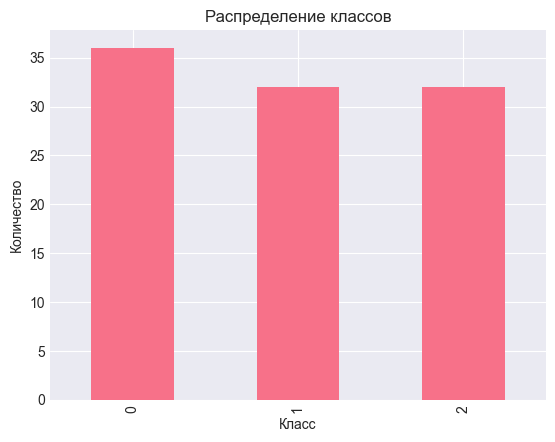

In [17]:
# Распределение классов
class_distribution = df_filled['Class'].value_counts().sort_index()
print(class_distribution)

# Визуализация
class_distribution.plot(kind='bar')
plt.title('Распределение классов')
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.show()

Анализ выбросов по каждому признаку:
F_0: 0 выборос(ов) (0.0%) Границы: -3.48,4.15
F_1: 0 выборос(ов) (0.0%) Границы: -3.00,2.94
F_2: 0 выборос(ов) (0.0%) Границы: -3.95,4.87
F_3: 0 выборос(ов) (0.0%) Границы: -1.78,1.83
F_4: 3 выборос(ов) (3.0%) Границы: -3.54,4.26
F_5: 0 выборос(ов) (0.0%) Границы: -4.00,3.44
F_6: 1 выборос(ов) (1.0%) Границы: -2.88,2.77
Class: 0 выборос(ов) (0.0%) Границы: -3.00,5.00


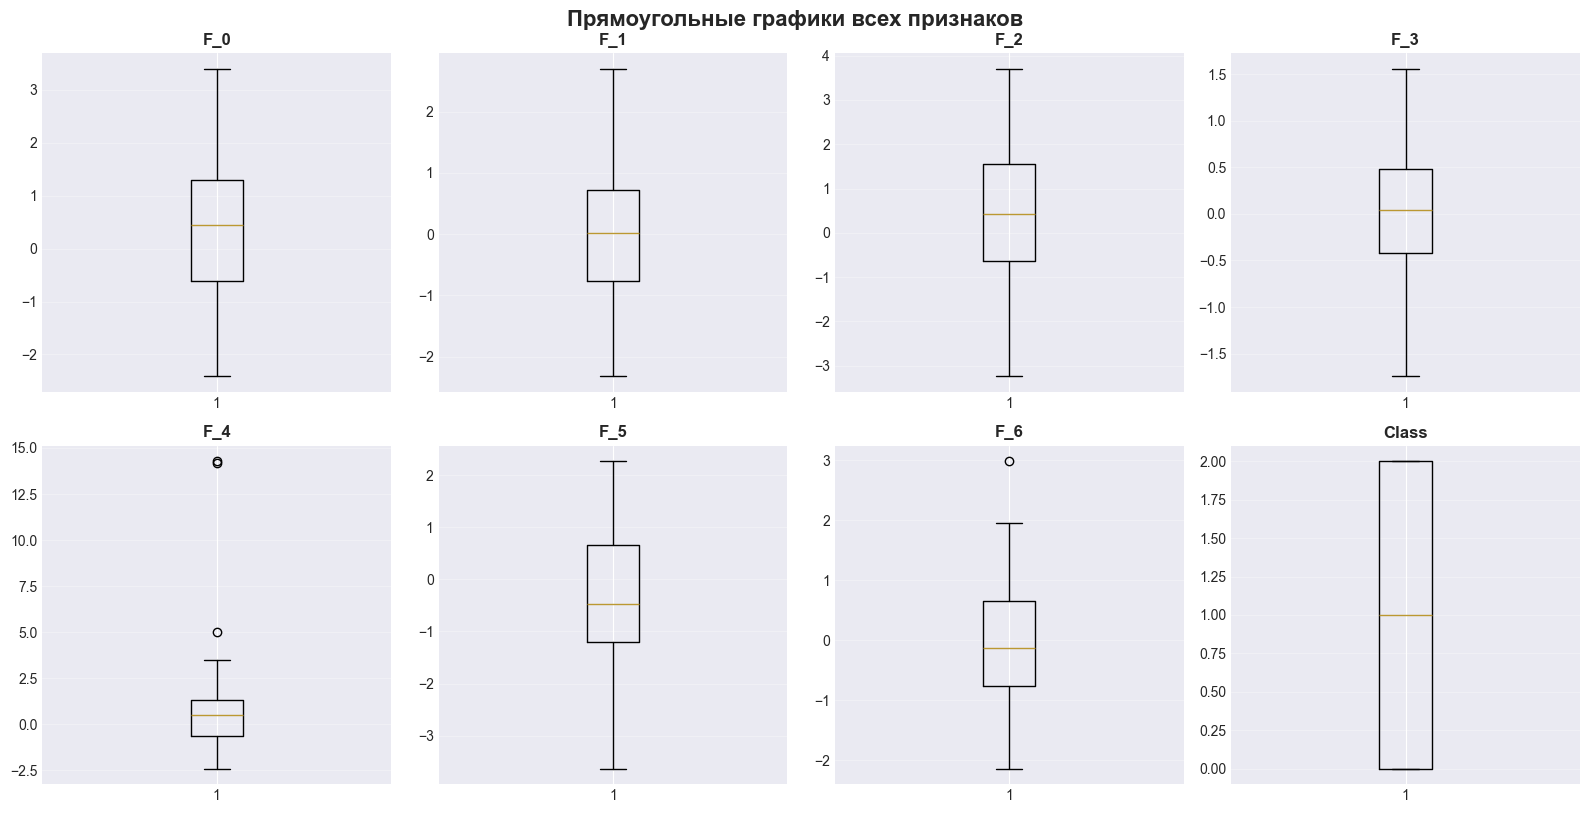

In [24]:
def detect_outliers_iqr(data,column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    
    return outliers, lower_bound, upper_bound

print("Анализ выбросов по каждому признаку:")
outliers_summary = {}
for col in df_filled.columns:
    outliers, lower, upper = detect_outliers_iqr(df_filled,col)
    outliers_summary[col] = len(outliers)
    print(f"{col}: {len(outliers)} выборос(ов) ({len(outliers)/len(df_filled) * 100:.1f}%)"
          f" Границы: {lower:.2f},{upper:.2f}")
    
# Визуальное распределение всех признаков
fig, axes = plt.subplots(2,4, figsize=(16,8)) 
axes = axes.ravel()

for idx, col in enumerate(df_filled.columns):
    axes[idx].boxplot(df_filled[col],vert=True)
    axes[idx].set_title(col,fontweight='bold')
    axes[idx].grid(axis='y',alpha=0.3)
    
plt.tight_layout()
plt.suptitle("Прямоугольные графики всех признаков", fontsize=16,fontweight='bold',y=1.01)
plt.show()

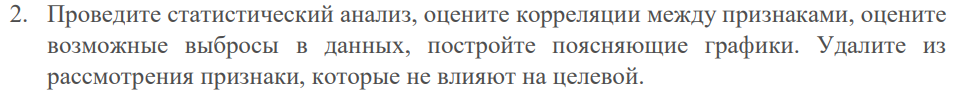

Матрица корреляций:
            F_0       F_1       F_2       F_3       F_4       F_5       F_6  \
F_0    1.000000 -0.036240  0.271906 -0.526284  0.647251  0.270480 -0.234344   
F_1   -0.036240  1.000000  0.055357  0.061271 -0.196515 -0.074104 -0.095769   
F_2    0.271906  0.055357  1.000000  0.658211  0.190725  0.285921  0.008605   
F_3   -0.526284  0.061271  0.658211  1.000000 -0.329463  0.072492  0.180267   
F_4    0.647251 -0.196515  0.190725 -0.329463  1.000000  0.290203 -0.038840   
F_5    0.270480 -0.074104  0.285921  0.072492  0.290203  1.000000 -0.086429   
F_6   -0.234344 -0.095769  0.008605  0.180267 -0.038840 -0.086429  1.000000   
Class  0.039250 -0.086745  0.038501  0.006373  0.141279  0.577812 -0.088746   

          Class  
F_0    0.039250  
F_1   -0.086745  
F_2    0.038501  
F_3    0.006373  
F_4    0.141279  
F_5    0.577812  
F_6   -0.088746  
Class  1.000000  

Корреляция признаков с целевым:
Class    1.000000
F_5      0.577812
F_4      0.141279
F_0      0.039250
F

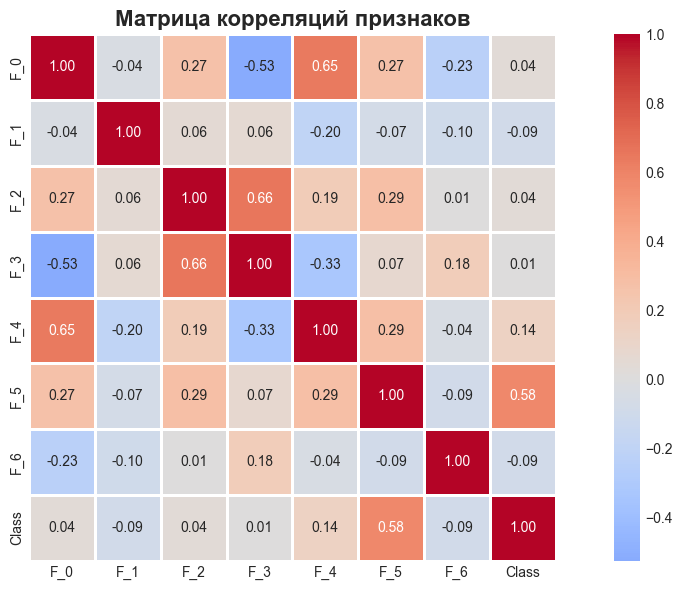

In [25]:
# Вычисление корреляций
correl_matrix = df_filled.corr()
print(f"Матрица корреляций:\n{correl_matrix}")

target_correl = correl_matrix['Class'].sort_values(ascending=False)
print(f"\nКорреляция признаков с целевым:\n{target_correl}")

# Визуализация корреляций
plt.figure(figsize=(12,6))
sns.heatmap(correl_matrix,annot=True,cmap='coolwarm',center=0,fmt='.2f',square=True,linewidths=1)
plt.title("Матрица корреляций признаков", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

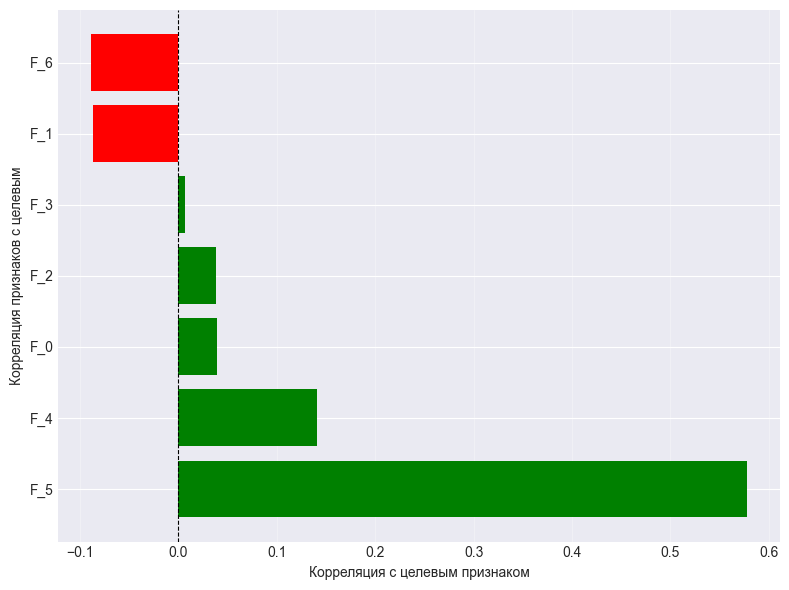

In [39]:
# Визуализация корреляции с целевым признаком
plt.figure(figsize=(8,6))
target_corr_sorted = target_correl.drop('Class')
colors = ['green' if x > 0 else 'red' for x in target_corr_sorted]
plt.barh(target_corr_sorted.index,target_corr_sorted.values,color=colors)

plt.xlabel("Корреляция с целевым признаком")
plt.ylabel("Корреляция признаков с целевым")

plt.axvline(x=0,color='black',linestyle="--",linewidth=0.8)
plt.grid(axis='x',alpha=0.3)
plt.tight_layout()

plt.show()

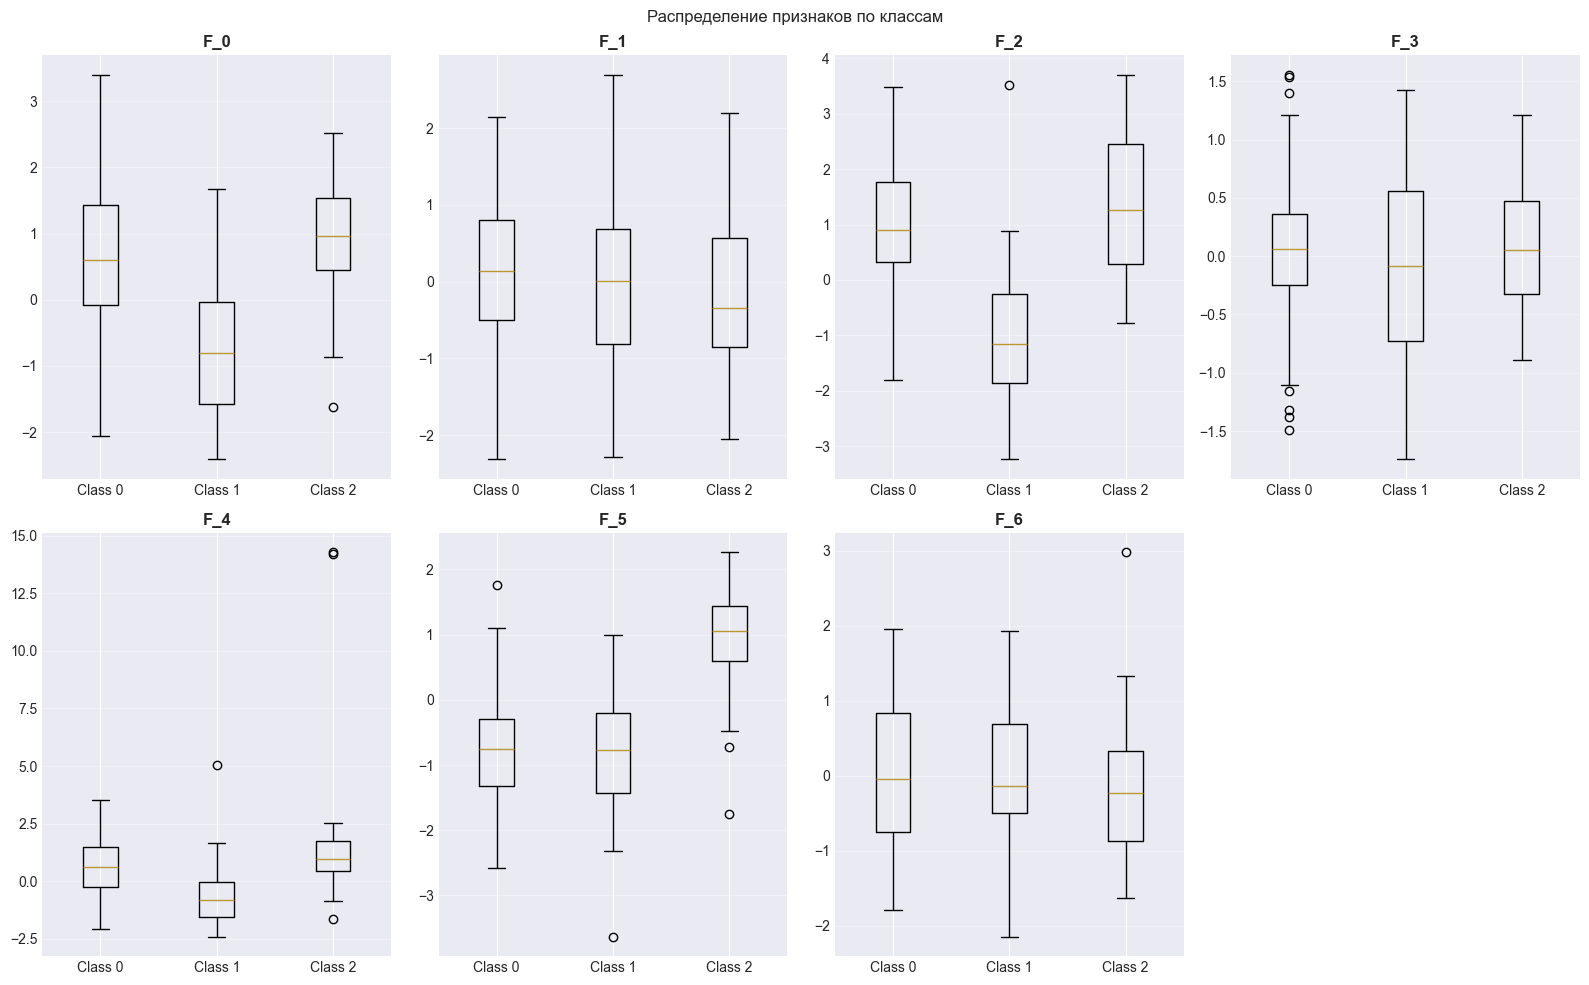

In [40]:
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(df_columns):
    class_data = [df_filled[df_filled['Class'] == cls][col].values 
                  for cls in sorted(df_filled['Class'].unique())]
    axes[idx].boxplot(class_data, 
                      labels=[f'Class {int(c)}' for c in sorted(df_filled['Class'].unique())])
    axes[idx].set_title(col, fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3)

for idx in range(len(df_columns), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Распределение признаков по классам')
plt.tight_layout()
plt.savefig('boxplots_by_class.png')
plt.show()


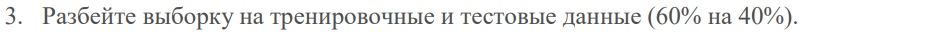

In [42]:
# Разбиение на признаки и целевую переменную
X = df_filled[df_columns].values
y = df_filled['Class'].values

# Нормализация признаков
scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)

# Разбиение 60% тренировочные, 40% тестовые
X_train, X_test, y_train, y_test = train_test_split(
    x_scaled, y, 
    test_size=0.4, 
    random_state=42, 
    stratify=y  # Сохранение распределения классов
)

print(f"Тренировочная выборка: {X_train.shape} образцов")
print(f"Тестовая выборка: {X_test.shape} образцов")

# Проверка распределения классов
print("\nТренировочная выборка:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"  Класс {int(cls)}: {count} ({count/len(y_train)*100:.1f}%)")

print("\nТестовая выборка:")
unique, counts = np.unique(y_test, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"  Класс {int(cls)}: {count} ({count/len(y_test)*100:.1f}%)")

Тренировочная выборка: (60, 7) образцов
Тестовая выборка: (40, 7) образцов

Тренировочная выборка:
  Класс 0: 22 (36.7%)
  Класс 1: 19 (31.7%)
  Класс 2: 19 (31.7%)

Тестовая выборка:
  Класс 0: 14 (35.0%)
  Класс 1: 13 (32.5%)
  Класс 2: 13 (32.5%)


In [43]:
print("После нормализации:")
print(f"Средние значения: {X_train.mean(axis=0)[:4].round(4)}")
print(f"Стд. отклонения: {X_train.std(axis=0)[:4].round(4)}")

После нормализации:
Средние значения: [ 0.081  -0.0074  0.0284 -0.0392]
Стд. отклонения: [1.0348 0.922  1.0482 1.0494]


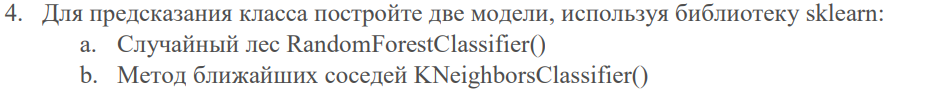

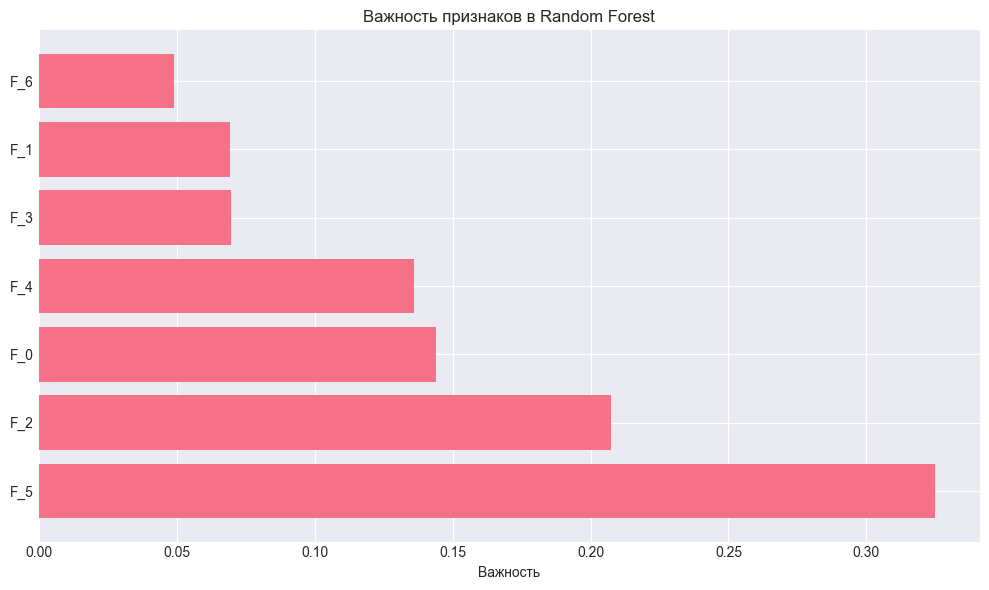

In [78]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1  # Параллелизм
)

rf_model.fit(X_train, y_train)

# Предсказание
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)

rf_f1_macro = f1_score(y_test, y_pred_rf, average='macro')

# Важность признаков
feature_importance = pd.DataFrame({
    'Feature': df_columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Визуализация
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Важность')
plt.title('Важность признаков в Random Forest')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

In [80]:
best_k = None
best_f1 = -1

for k in range(3, 15):
    model = KNeighborsClassifier(n_neighbors=k, weights='distance', metric='euclidean')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='macro')

    if f1 > best_f1:
        best_f1 = f1
        best_k = k

print(f"Оптимальное количество соседей: {best_k}")
# Создание и обучение модели
knn_model = KNeighborsClassifier(
    n_neighbors=best_k,
    weights='distance',
    metric='euclidean',
    algorithm='auto'
)

knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

knn_f1_macro = f1_score(y_test, y_pred_knn, average='macro')

# Предсказание
y_pred_knn = knn_model.predict(X_test)
y_pred_proba_knn = knn_model.predict_proba(X_test)

def choose_best_model(knn_result, rf_result):
    if rf_result > knn_result:
        return "RandomForestClassifier",rf_result
    return "KNeighborsClassifier",knn_result


best_name, best_result = choose_best_model(knn_f1_macro, rf_f1_macro)
print(f"Лучшая модель:\n{best_name} - {best_result}")

Оптимальное количество соседей: 6
Лучшая модель:
KNeighborsClassifier - 0.8001763668430334


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

